# Graph classification sweep performance - Region label prediction

Chen et al, 2022 data with condition labes (Mid-AD and Control)

**Part 1: Hyperparam sweep**

Plots showing the performance for the region label classification.

**Part 2: Graph label prediction performance**

- InterScale (GCN + Transformer)
- GCN
- PCATransformer



In [5]:
import os

# LRZ home
if os.path.exists("/dss/dsshome1/05/di93tig"):
    print('LRZ cluster')
    CLUSTER = 'LRZ'
    BASE_DIR_REPO = "/dss/dsshome1/05/di93tig/1_projects/InterScale_reproducibility" 
    BASE_DIR_PROJECT = "/dss/dssfs03/tumdss/pn36po/pn36po-dss-0002/di93tig/Projects/A3_InterScale"
elif os.path.exists("/home/icb/francesca.drummer/"):
    print('HPC cluster')
    CLUSTER = 'HPC'
    BASE_DIR_REPO = "/home/icb/francesca.drummer/1-Projects/"
    BASE_DIR_PROJECT = ""
else:
    print('unkown')
    CLUSTER = 'unknown'
    BASE_DIR_REPO = "/Users/francesca.drummer/Documents/2_Areas/A3-InterScale/code/InterScale_reproducibility"
DATA = "chen22"

unkown


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [6]:
import sys
from pathlib import Path

# Add project root to path (go up 2 levels from notebook location)
project_root = Path(f'{BASE_DIR_REPO}')
print(project_root)
sys.path.insert(0, str(project_root))

/Users/francesca.drummer/Documents/2_Areas/A3-InterScale/code/InterScale_reproducibility


In [8]:
import wandb
wandb.login()

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: Enter your choice:wandb: Enter your choice:wandb: Enter your choice:wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:



KeyboardInterrupt: 

In [ ]:
import pandas as pd
# plotting libraries
import seaborn as sns
import matplotlib.pyplot as plt
# InterScale imports
from InterScale.config import load_config, config_from_wandb_run

# utility function imports
from src.wandb import Wandb_evaluation, plot_f1_across_seeds, plot_class_f1_comparison, set_plot_configs
from src.plots import Plotting
from src.utils import set_full_reproducibility

In [6]:
import yaml
import matplotlib.pyplot as plt
import scanpy as sc

config_path = os.path.join(BASE_DIR_REPO, "figures/config.yml")

with open(config_path, "r") as f:
    config = yaml.safe_load(f)

PALETTE = config["palettes"]["continuous"]
CELL_TYPE_COLORS = config["palettes"][DATA]

from figures.scripts.plots import Plotting

plotting = Plotting(config_path)
plotting._setup_plotting_params()

## Hyperparameter sweep

Evaluation of node-classification (Cell type) hyperparameter sweep.

In [37]:
InterScale_wandb = "3pfj292b"
SWEEP_GOAL = "graph"
CLASSES = ["control", "Mid-AD"]

In [38]:
InterScale_sweep = Wandb_evaluation("InterScale", InterScale_wandb, True, True, SWEEP_GOAL, CLASSES)

In [28]:
df = InterScale_sweep.filter_runs(exclude_parameters = {})
df.head()

,id,name,seed,state,pct_mask_nodes,radius,decoder_type,runtime_seconds,total_parameters,test_acc,test_f1_micro,test_f1_macro,test_f1_class_control,test_f1_class_Mid-AD
0,ctax3l9b,Chen22_clas_graph_40_GCN_self-attn-transformer_,None,finished,0.50,None,None,128,700882,0.5,0.5,0.500000,0.5,0.500000
1,akk7eix8,Chen22_clas_graph_40_GCN_self-attn-transformer_,None,finished,0.00,None,None,50,309842,0.5,0.5,0.333333,0.0,0.666667
2,m87tsca8,Chen22_clas_graph_40_GCN_self-attn-transformer_,None,finished,0.50,None,None,69,1148322,0.5,0.5,0.333333,0.0,0.666667
3,99a2t19i,Chen22_clas_graph_40_GCN_self-attn-transformer_,None,finished,0.50,None,None,50,627362,0.5,0.5,0.333333,0.0,0.666667
4,mrdhjnfo,Chen22_clas_graph_40_GCN_self-attn-transformer_,None,finished,0.25,None,None,67,294818,0.5,0.5,0.500000,0.5,0.500000


In [29]:
df[df['test_f1_micro'] > 0.55]

,id,name,seed,state,pct_mask_nodes,radius,decoder_type,runtime_seconds,total_parameters,test_acc,test_f1_micro,test_f1_macro,test_f1_class_control,test_f1_class_Mid-AD
15,0bn9fg6a,Chen22_clas_graph_40_GCN_self-attn-transformer_,None,finished,0.80,None,None,96,658754,0.625000,0.625000,0.563636,0.727273,0.400000
20,w8wg9uz9,Chen22_clas_graph_40_GCN_self-attn-transformer_,None,finished,0.00,None,None,116,1286978,0.625000,0.625000,0.563636,0.400000,0.727273
21,w03qpfzo,Chen22_clas_graph_40_GCN_self-attn-transformer_,None,finished,0.25,None,None,80,795138,0.812500,0.812500,0.781818,0.363636,0.700000
25,9wbfzyzs,Chen22_clas_graph_40_GCN_self-attn-transformer_,None,finished,0.50,None,None,58,356674,0.750000,0.750000,0.733333,0.666667,0.800000
28,lq4zyhaa,Chen22_clas_graph_40_GCN_self-attn-transformer_,None,finished,0.50,None,None,49,170402,0.642857,0.642857,0.590643,0.444444,0.736842
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
382,tzifyvx2,Chen22_clas_graph_40_GCN_self-attn-transformer_,None,finished,0.80,None,None,34,778370,0.625000,0.625000,0.563636,0.727273,0.400000
385,5llenh6i,Chen22_clas_graph_40_GCN_self-attn-transformer_,None,finished,0.80,None,None,21,356674,0.571429,0.571429,0.475000,0.250000,0.700000
387,h7kndr50,Chen22_clas_graph_40_GCN_self-attn-transformer_,None,finished,0.50,None,None,13,778370,0.625000,0.625000,0.563636,0.400000,0.727273
390,oeve6ii9,Chen22_clas_graph_40_GCN_self-attn-transformer_,None,finished,0.00,None,None,20,1612498,0.625000,0.625000,0.563636,0.400000,0.727273


In [33]:
df[(df['test_f1_class_control'] > 0.55) & (df['test_f1_class_Mid-AD'] > 0.55)].sort_values('test_f1_macro', ascending=False)

,id,name,seed,state,pct_mask_nodes,radius,decoder_type,runtime_seconds,total_parameters,test_acc,test_f1_micro,test_f1_macro,test_f1_class_control,test_f1_class_Mid-AD
190,9b7h1hmn,Chen22_clas_graph_40_GCN_self-attn-transformer_,None,finished,0.80,None,None,45,2990338,0.875000,0.875000,0.873016,0.857143,0.888889
303,8ftz1oil,Chen22_clas_graph_40_GCN_self-attn-transformer_,None,finished,0.50,None,None,21,590562,0.875000,0.875000,0.873016,0.857143,0.888889
240,mx871hq6,Chen22_clas_graph_40_GCN_self-attn-transformer_,None,finished,0.50,None,None,42,2462978,0.875000,0.875000,0.873016,0.857143,0.888889
326,ntyfsnye,Chen22_clas_graph_40_GCN_self-attn-transformer_,None,finished,0.00,None,None,28,170402,0.857143,0.857143,0.857143,0.857143,0.857143
231,t6ns4rfb,Chen22_clas_graph_40_GCN_self-attn-transformer_,None,finished,0.25,None,None,46,2462978,0.857143,0.857143,0.854167,0.833333,0.875000
253,51xuldq2,Chen22_clas_graph_40_GCN_self-attn-transformer_,None,finished,0.50,None,None,48,1818370,0.857143,0.857143,0.854167,0.833333,0.875000
92,cm28si1k,Chen22_clas_graph_40_GCN_self-attn-transformer_,None,finished,0.80,None,None,54,1380898,0.785714,0.785714,0.775401,0.727273,0.823529
292,6tks30nz,Chen22_clas_graph_40_GCN_self-attn-transformer_,None,finished,0.50,None,None,29,795138,0.750000,0.750000,0.750000,0.750000,0.750000
327,v1oa6bm9,Chen22_clas_graph_40_GCN_self-attn-transformer_,None,finished,0.80,None,None,20,1595522,0.750000,0.750000,0.750000,0.750000,0.750000
25,9wbfzyzs,Chen22_clas_graph_40_GCN_self-attn-transformer_,None,finished,0.50,None,None,58,356674,0.750000,0.750000,0.733333,0.666667,0.800000


In [36]:
InterScale_sweep.export_config_to_yaml(best_run_id="waj87gc6", save_path=f"{BASE_DIR_REPO}/chen22_best_config.yaml")

Config saved to /dss/dsshome1/05/di93tig/1_projects/InterScale_reproducibility/chen22_best_config.yaml


'/dss/dsshome1/05/di93tig/1_projects/InterScale_reproducibility/chen22_best_config.yaml'

## 1. Robustness sweep

Run robustness sweep with config.yaml from best model. 

In [7]:
adata = sc.read_h5ad(os.path.join(BASE_DIR_PROJECT, "data/melton25.h5ad"))

### Load WandB IDs

In [7]:
GNN_sweep = "39pecmnt"
InterScale_sweep = "3pfj292b"
PCATrans_sweep = "tohmr60x"

## Graph Classification performance

In [8]:
SWEEP_GOAL = 'robustness'
CLASSES = ["control", "Mid-AD"]

Q: Why does PCATrans not have test_f1 scores?

In [10]:
GNN_wandb = Wandb_evaluation("GCN", GNN_sweep, True, False, SWEEP_GOAL, CLASSES)
PCATrans_wandb = Wandb_evaluation("PCATransformer", PCATrans_sweep, False, True, SWEEP_GOAL, CLASSES)
InterScale_wandb = Wandb_evaluation("InterScale", InterScale_sweep, True, True, SWEEP_GOAL, CLASSES)

In [10]:
GNN_wandb.get_mean_and_std()

,pct_mask_nodes,radius,mean_test_acc,std_test_acc,mean_test_f1_class_0,std_test_f1_class_0,mean_test_f1_class_1,std_test_f1_class_1
0,0.25,NaN,0.4,0.223607,0.133333,0.298142,0.400000,0.365148
1,0.50,NaN,0.5,0.176777,0.346667,0.334664,0.426667,0.393277
2,0.80,NaN,0.5,0.000000,0.266667,0.365148,0.400000,0.365148


In [11]:
InterScale_wandb

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


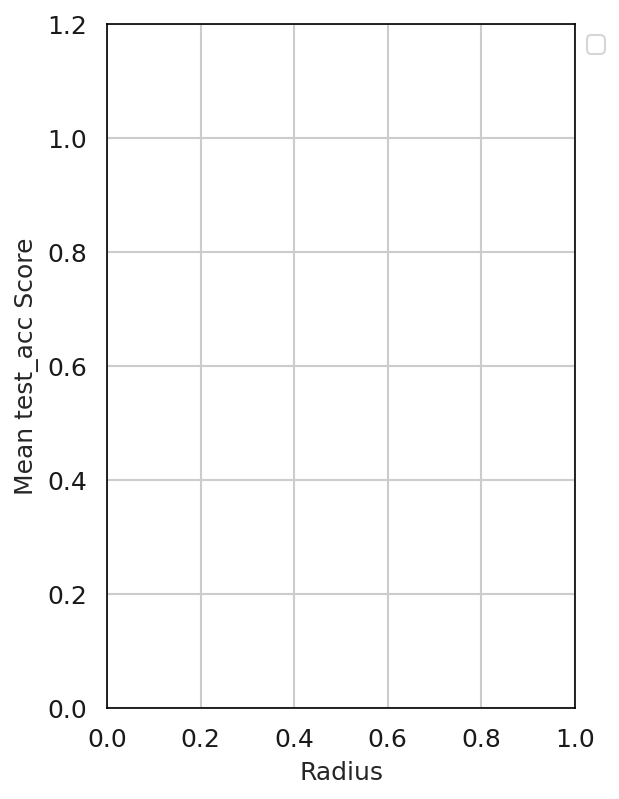

In [21]:
GNN_wandb.plot_robustness(metric="test_acc", save_path = f"{BASE_DIR_REPO}/figures/{DATA}/node_class")

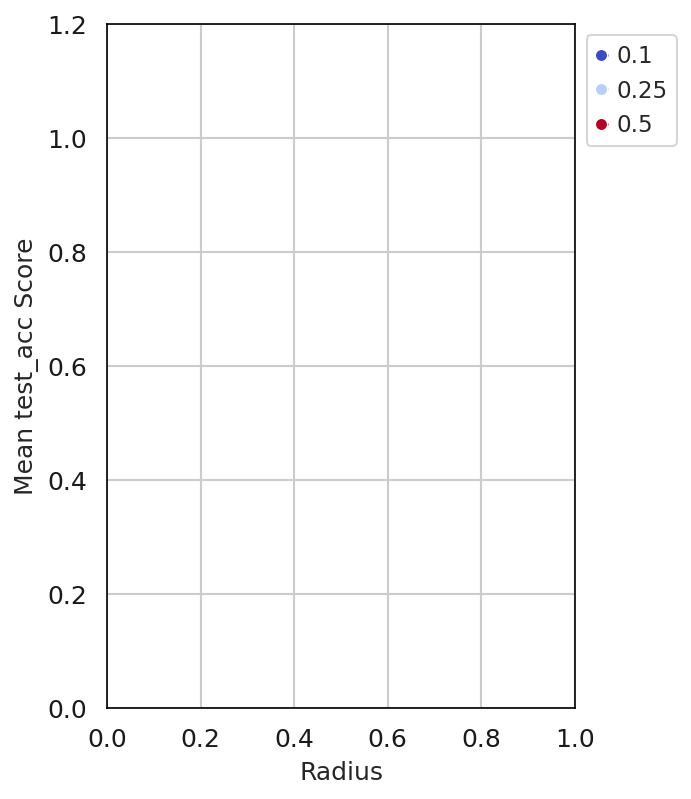

In [19]:
InterScale_wandb.plot_robustness(metric="test_acc", save_path =  f"{BASE_DIR_REPO}/figures/{DATA}/graph_class")

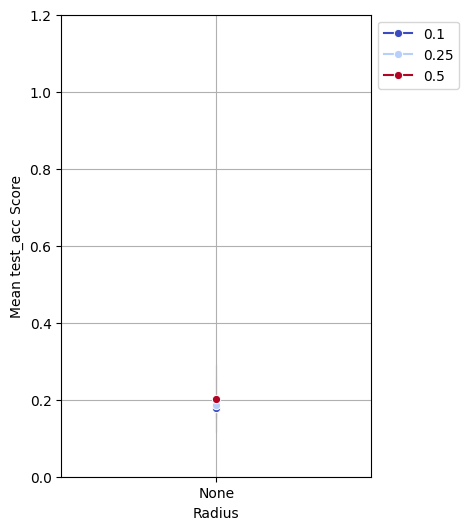

In [18]:
PCATrans_wandb.plot_robustness(metric="test_acc", save_path =  f"{BASE_DIR_REPO}/InterScale_reproducibility/figures/{DATA}/node_class")

## F1 score performance

In [16]:
#wandb_evals = [GNN_wandb, PCATrans_wandb, DualInterScale_wandb]  # Your list of dataframes, PCATrans_wandb, InterScale_wandb
wandb_evals = [GNN_wandb, InterScale_wandb, PCATrans_wandb] 

In [17]:
def plot_f1_across_seeds(wandb_evaluations, 
                         radius, 
                         pct_mask_nodes, 
                         BASE_DIR_REPO, 
                         height=4, 
                         aspect=0.7,
                         save_path=None,
                         dropna=True):
    """
    Plot mean and standard deviation of per-class F1 scores across seeds.
    Uses seaborn catplot with one facet per class and one bar per model.
    
    Parameters:
    -----------
    wandb_evaluations : list of Wandb_evaluation
        List of Wandb_evaluation instances, one per model
    radius : float or int or None
        Radius value to filter by
    pct_mask_nodes : float or int or None
        Percentage of masked nodes to filter by
    config_path : str, optional
        Path to config.yml file (default: 'config.yml')
    height : float, optional
        Height of each facet in inches (default: 4)
    aspect : float, optional
        Aspect ratio of each facet (default: 0.7)
    save_path: str
        Path name from repo to save the plot.
    dropna : bool, optional
        Whether to drop rows with NaN in 'radius' or 'pct_mask_nodes' (default: True).
        Set to False if radius or pct_mask_nodes is None.
    
    Returns:
    --------
    g : seaborn FacetGrid
        The catplot object
    stats_df : pd.DataFrame
        DataFrame with mean and std for each class and model
    plot_data : pd.DataFrame
        Long-form data used for plotting
    """
    general_config, model_palette = set_plot_configs(BASE_DIR_REPO)

    # Process each Wandb_evaluation instance
    all_data = []
    model_names = []
    
    for wandb_eval in wandb_evaluations:
        model_name = wandb_eval.model
        classes = wandb_eval.classes
        
        model_names.append(model_name)
        
        df = wandb_eval.df.dropna(subset=["radius", "pct_mask_nodes"]) if dropna else wandb_eval.df

        # Filter by specified parameters
        if radius is None:
            mask_radius = df['radius'].isna()
        else:
            mask_radius = df['radius'] == radius

        if pct_mask_nodes is None:
            mask_pct = df['pct_mask_nodes'].isna()
        else:
            mask_pct = df['pct_mask_nodes'] == pct_mask_nodes

        df_filtered = df[mask_radius & mask_pct].copy()
        
        if df_filtered.empty:
            print(f"Warning: No data found for {model_name} with radius={radius}, pct_mask_nodes={pct_mask_nodes}")
            continue
        
        # Identify F1 score columns
        f1_cols = [col for col in df_filtered.columns if col.startswith('test_f1_class_')]
        
        if not f1_cols:
            raise ValueError(f"No 'test_f1_class_*' columns found in {model_name}")
        
        # Add model label
        df_filtered['model'] = model_name
        
        # Collect the data
        all_data.append(df_filtered)
    
    if not all_data:
        raise ValueError("No data found matching the specified parameters")
    
    # Combine all dataframes
    combined_df = pd.concat(all_data, ignore_index=True)
    
    # Identify F1 columns
    f1_cols = [col for col in combined_df.columns if col.startswith('test_f1_class_')]
    
    # Reshape to long format for seaborn
    plot_data = combined_df.melt(
        id_vars=['model'],
        value_vars=f1_cols,
        var_name='class',
        value_name='f1_score'
    )
    
    # Clean up class names
    plot_data['class'] = plot_data['class'].str.replace('test_f1/class_', '')
    
    # Calculate statistics for reference
    stats_df = plot_data.groupby(['model', 'class'])['f1_score'].agg([
        ('mean', 'mean'),
        ('std', 'std'),
        ('n_seeds', 'count')
    ]).reset_index()

    print(stats_df)
    
    # Create color palette based on model names from config
    palette = []
    for model_name in model_names:
        if model_name in model_palette:
            palette.append(model_palette[model_name])
        else:
            print(f"Warning: Model '{model_name}' not found in config palette. Using default color.")
            palette.append(None)
    
    # If all models are in config, use the palette; otherwise let seaborn handle it
    use_palette = palette if all(c is not None for c in palette) else None
    
    # Create the catplot
    g = sns.catplot(
        data=plot_data,
        kind="bar",
        x="class",
        y="f1_score",
        hue="model",
        height=height,
        aspect=aspect,
        errorbar="sd",
        capsize=0.1,
        edgecolor="black",
        linewidth=1.0,
        alpha=0.8,
        palette=use_palette,
        legend=False
    )
    
    # Customize the plot with config settings
    g.set_axis_labels(
        "Model", 
        "Test F1 Score", 
        fontsize=general_config['legend_fontsize'],
        fontweight=general_config['legend_fontweight']
    )
    g.set_titles(
        "Class: {col_name}", 
        fontsize=general_config['title_fontsize'],
        fontweight=general_config['title_fontweight']
    )
    
    # Set y-axis limits and grid
    for ax in g.axes.flat:
        ax.set_ylim([0, 1.2])
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_axisbelow(True)
    
    # Rotate x-axis labels if needed
    for ax in g.axes.flat:
        ax.tick_params(axis='x', rotation=45)
        for label in ax.get_xticklabels():
            label.set_ha('right')
    
    # Overall title
    g.fig.suptitle(
        f'F1 Scores Across Seeds (radius={radius}, pct_mask={pct_mask_nodes})',
        fontsize=general_config['title_fontsize'],
        fontweight=general_config['title_fontweight'],
        y=1.02
    )
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(
            os.path.join(BASE_DIR_REPO, 'figures/', f'{save_path}.jpg'),
            dpi=300, bbox_inches='tight'
        )
    
    plt.show()
    
    return g, stats_df, plot_data

## Class robustness

            model                  class      mean       std  n_seeds
0             GCN   test_f1_class_Mid-AD  0.426667  0.393277        5
1             GCN  test_f1_class_control  0.346667  0.334664        5
2      InterScale   test_f1_class_Mid-AD  0.553074  0.320331        5
3      InterScale  test_f1_class_control  0.480000  0.292119        5
4  PCATransformer   test_f1_class_Mid-AD  0.345455  0.349209        5
5  PCATransformer  test_f1_class_control  0.466667  0.282843        5


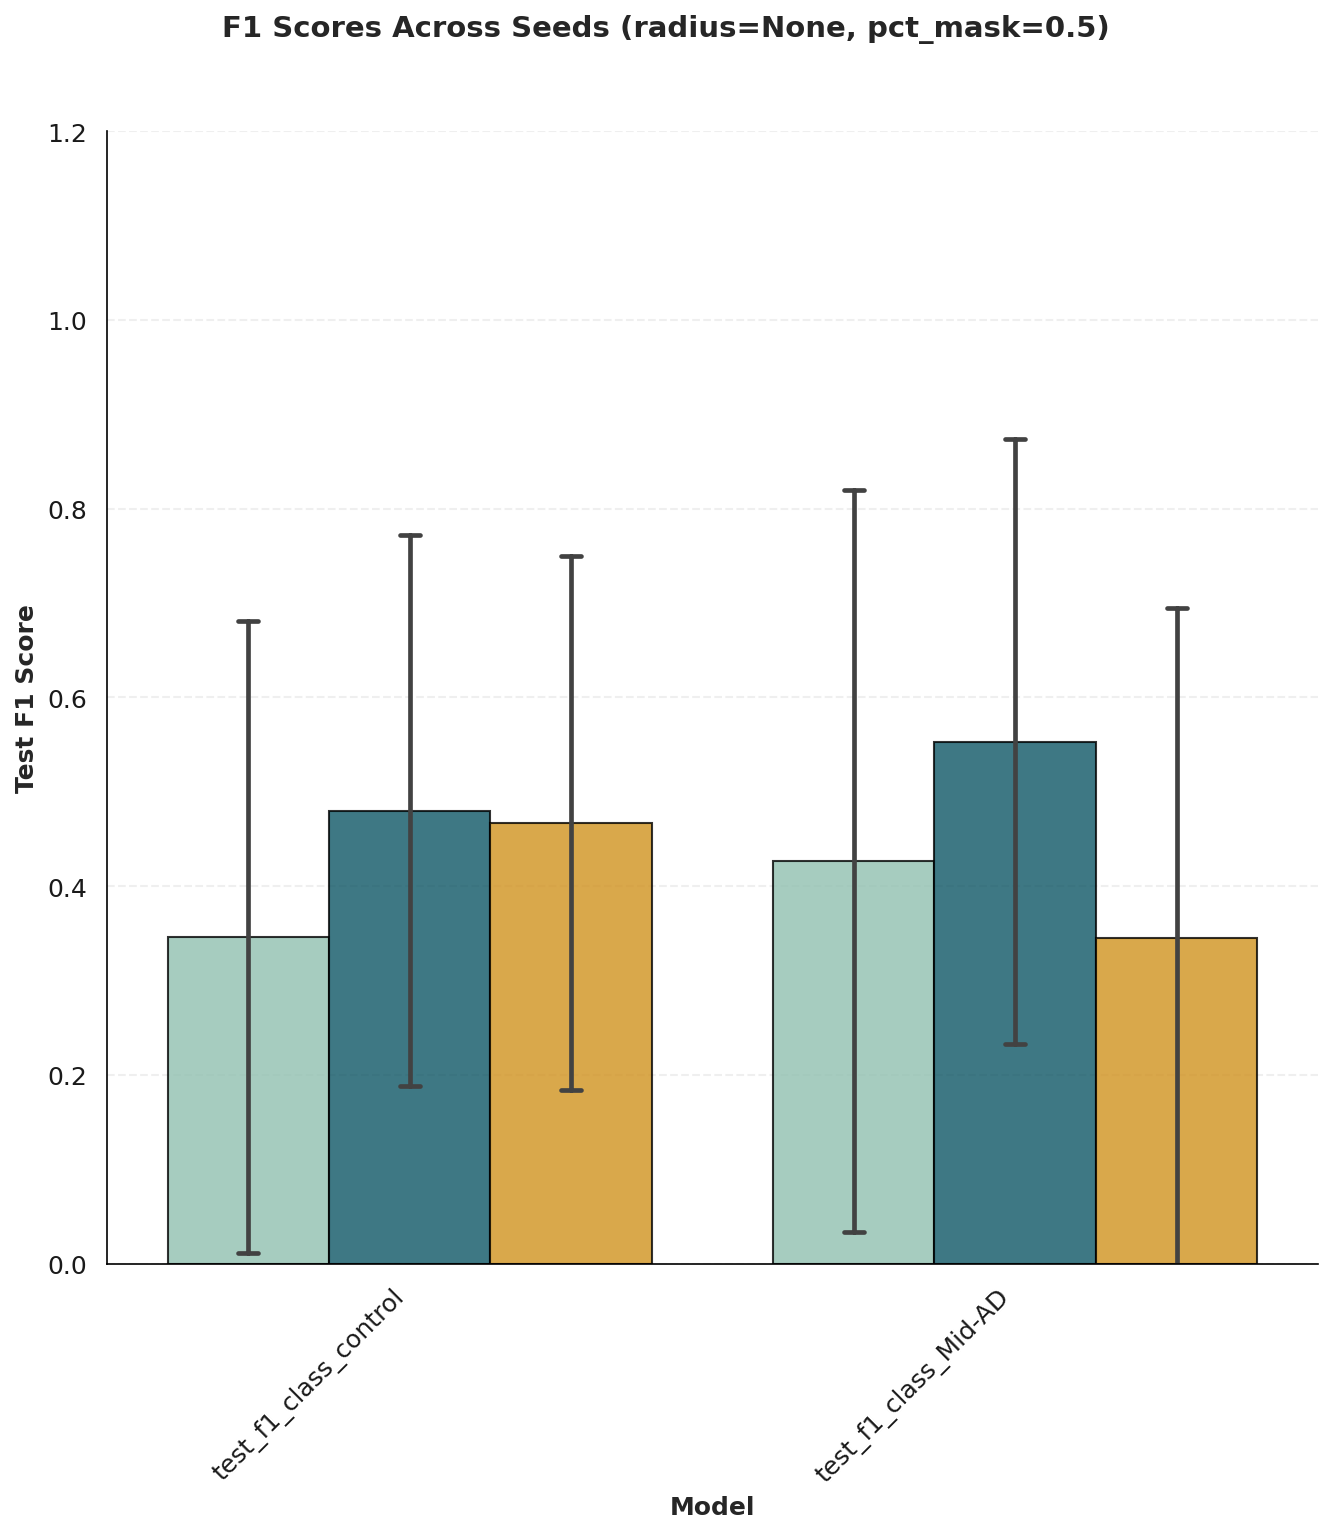

In [21]:
r = None
pct_mask = 0.5

g, stats, plot_data = plot_f1_across_seeds(
    wandb_evaluations=wandb_evals,
    radius=r,
    pct_mask_nodes=pct_mask,
    BASE_DIR_REPO=BASE_DIR_REPO, 
    height=10,
    aspect=0.9,
    save_path=f'{DATA}/graph_class/f1_comparison_models_{r}_{pct_mask}',
    dropna = False
)
plt.show()
#
# # Save with high DPI from config
# # g.savefig('f1_scores.png', bbox_inches='tight')
#
# # Print statistics:
# print(stats)

## Overall performance

How do the models perform overall? PLot Macro F1, Micro F1 & Accuracy.

In [24]:
def plot_overall_metric_comparison(wandb_evaluations, metric, radius=None, pct_mask_nodes=None, 
                                   BASE_DIR_REPO=None, save_path=None, figsize=(8, 5), dropna=True):
    """
    Plot overall performance for a specific metric across models (aggregated across seeds).
    
    Parameters:
    -----------
    wandb_evaluations : list of Wandb_evaluation
    metric : str
        Column name of the metric to plot (e.g., 'test_f1_macro', 'test_accuracy', 'test_loss')
    radius, pct_mask_nodes : filter values (optional, use None to match NaN rows)
    BASE_DIR_REPO : str
    save_path : str, optional
    figsize : tuple
    dropna : bool, optional
        Whether to drop rows with NaN in 'radius' or 'pct_mask_nodes' (default: True).
        Set to False if radius or pct_mask_nodes is None.
    
    Returns:
    --------
    fig, ax, stats_df
    """
    general_config, model_palette = set_plot_configs(BASE_DIR_REPO)
    
    all_data = []
    
    for wandb_eval in wandb_evaluations:
        model_name = wandb_eval.model
        df = wandb_eval.df.dropna(subset=["radius", "pct_mask_nodes"]) if dropna else wandb_eval.df.copy()

        # Filter by radius
        if radius is None:
            df = df[df['radius'].isna()]
        else:
            df = df[df['radius'] == radius]

        # Filter by pct_mask_nodes
        if pct_mask_nodes is None:
            df = df[df['pct_mask_nodes'].isna()]
        else:
            df = df[df['pct_mask_nodes'] == pct_mask_nodes]
        
        if df.empty:
            print(f"Warning: No data for {model_name} with specified filters")
            continue
        
        if metric not in df.columns:
            print(f"Warning: Metric '{metric}' not found for {model_name}")
            continue
        
        plot_df = df[['seed', metric]].copy() if 'seed' in df.columns else df[[metric]].copy()
        plot_df['model'] = model_name
        all_data.append(plot_df)
    
    if not all_data:
        raise ValueError("No valid data found for any model")
    
    combined_df = pd.concat(all_data, ignore_index=True)
    
    # Statistics
    stats_df = combined_df.groupby('model')[metric].agg([
        ('mean', 'mean'),
        ('std', 'std'),
        ('n_seeds', 'count')
    ]).reset_index()
    print(stats_df)
    
    # Build palette
    palette = {m: model_palette[m] for m in combined_df['model'].unique() if m in model_palette}
    
    fig, ax = plt.subplots(figsize=figsize)
    
    models = stats_df['model'].tolist()
    means = stats_df['mean'].tolist()
    stds = stats_df['std'].tolist()
    colors = [palette.get(m, None) for m in models]
    
    x = np.arange(len(models))
    bar_width = 0.6
    ax.set_xlim(-0.4, len(models) - 0.4)
    
    ax.bar(x, means, yerr=stds, width=bar_width, color=colors,
           edgecolor='black', linewidth=1.0, alpha=0.8, capsize=4)
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    metric_label = metric.replace('_', ' ').replace('test ', '').title()
    ax.set_xlabel('Model', fontsize=general_config['legend_fontsize'], 
                  fontweight=general_config['legend_fontweight'])
    ax.set_ylabel(metric_label, fontsize=general_config['legend_fontsize'], 
                  fontweight=general_config['legend_fontweight'])
    ax.set_title(f'{metric_label} Across Seeds (radius={radius}, pct_mask={pct_mask_nodes})',
                 fontsize=general_config['title_fontsize'], 
                 fontweight=general_config['title_fontweight'])
    
    ax.set_ylim([0, 1.05])
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    ax.tick_params(axis='x', rotation=45)
    for label in ax.get_xticklabels():
        label.set_ha('right')
    
    plt.tight_layout()
    
    if save_path is not None:
        plt.savefig(
            os.path.join(BASE_DIR_REPO, 'figures/', f'{save_path}.jpg'),
            dpi=300, bbox_inches='tight'
        )
    
    plt.show()
    
    return fig, ax, stats_df

            model   mean       std  n_seeds
0             GCN  0.500  0.176777        5
1      InterScale  0.600  0.104583        5
2  PCATransformer  0.525  0.055902        5


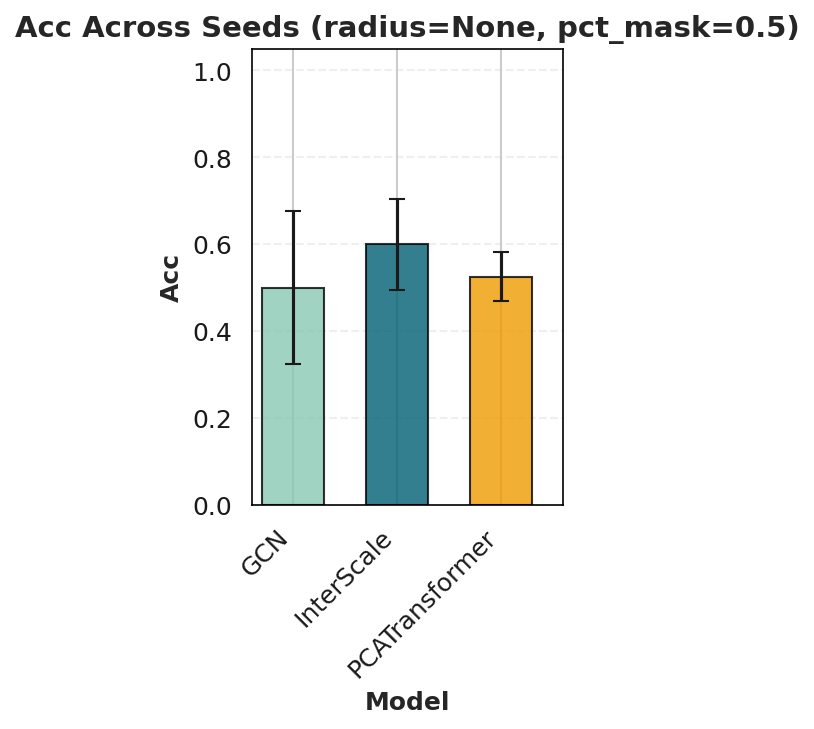

In [25]:
import numpy as np

fig, ax, stats = plot_overall_metric_comparison(
    wandb_evals,
    metric='test_acc',  # or 'test_accuracy', 'test_balanced_accuracy', etc.
    radius=None,
    pct_mask_nodes=0.5,
    BASE_DIR_REPO=BASE_DIR_REPO,
    save_path=f'{DATA}/graph_class/overall_f1_comparison_models_{r}_{pct_mask}',
    figsize=(3, 5), 
   dropna=False
)